# CS 105 Final Project 

### Daniel Coelho, Truman Fung, Carolyn Hsu, Nicole Chen, Liam Renehan, Aaron Garcia

## Project Proposal 

Our project aims to predict whether a patient’s tumor is benign or malignant based on 8 features that we will use as predictor features\. The features are all related to the cells that were obtained from the patient’s tumor\. The dataset we are using is from the Original Wisconsin Breast Cancer Database and stored on downloaded from the UCI database from 1992\. By using various selection techniques, we can determine which features are most important and then use them for supervised and unsupervised learning algorithms\. The data for the 8 features are on a scale of 1 through 10 where 1 means that the cells are normal and 10 means there are severe abnormalities in the cells\. We plan on handling missing data by simply removing the data entries with missing data, as having inference data could lead to a misdiagnosis\. We will use different EDA techniques to analyze the data thoroughly and try and find patterns and correlations if they exist\. We then will use different supervised and unsupervised prediction techniques to see if we can predict different diagnoses\.  

## Dataset

Chosen Dataset: Breast Cancer Wisconsin \(Original\) 

https://archive\.ics\.uci\.edu/dataset/15/breast\+cancer\+wisconsin\+original

## Slides

https://docs\.google\.com/presentation/d/1cO\-QDGRdhtQoINcZPPT2wU9Fgm4ko\_7J70\_nlYbG\_5E/edit\#slide=id\.p 

## Contributions 

Daniel Coelho \- Data Cleaning, Bar Chart, Tests, K\-NN with Forward Feature Selection 

Truman Fung \- Logistic Regression, K\-NN

Carolyn Hsu \- Heat Map, K\-Means Elbow, DBSCAN

Nicole Chen \- K\-Means Clustering 

Liam Renehan \- Histograms

Aaron Carmen \- Chi\-Square Tests

## Techniques

EDA

 \- Visualizations and Models: Bar Charts, Histogram, Heat Map

 \- Tests: Pearson Correlation Test, Chi Square Test

We used bar charts, histograms, and heat maps to help us better visualize the data we are using in order to visually see patterns that might exist\.  By having different visuals we are able to see patterns and trends or also see features we might want to focus more on\. The Pearson Correlation test and Chi Square test gave us quantitative insight into which features are the more significant and important features in predicting a diagnosis\. 

Predictions

 \- Supervised Learning: Logistic Regression, K\-NN, K\-NN with Forward Feature Selection

We used logistic regression and K Nearest Neighbors because they are both supervised learning techniques that apply very well with our dataset and prediction goals\. Logistic regression is a binary classifier which is perfect for us as we are trying to classify either malignant or benign\. We used K\-NN in order to predict new data based on potentially similar data\. K\-NN with Forward Feature Selection was used to see if we could get better results with only accounting for the four best features instead of all the features\.

 \- Unsupervised Learning: K\-Means Clustering, DBSCAN

For unsupervised learning we used K\-Means Clustering and DBSCAN so we could see if unsupervised learning techniques provided better or worse predictions than the supervised learning\. K\-Means was a good choice because we can plot our data and use clustering to see if new test data was able to be accurately classified\. DBSCAN was used as a comparison to K\-Means clustering as a way to see if a potential non\-convex shape existed in the data and DBSCAN was able to use it to accurately predict diagnoses\. 

## Data Cleaning 

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import chi2_contingency
from sklearn import metrics
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
# Daniel

columns = ['Sample_code_number', 'Clump_thickness', 'Uniformity_of_cell_size', 
           'Uniformity_of_cell_shape', 'Marginal_adhesion', 'Single_epithelial_cell_size',
           'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses', 'Class']

bcw_df = pd.read_csv('breast-cancer-wisconsin.data', names=columns, na_values='?')

# Map Class 2 benign and 4 malignant to 0s and 1s
bcw_df['Class'] = bcw_df['Class'].map({2: 0, 4: 1})

# Convert Bare_nuclei to numeric and drop rows with missing values
bcw_df['Bare_nuclei'] = pd.to_numeric(bcw_df['Bare_nuclei'], errors='coerce')  
bcw_df = bcw_df.dropna(subset=['Bare_nuclei'])  
bcw_df.rename(columns={'Sample_code_number': 'ID'}, inplace=True)

bcw_df.to_csv('cleaned_breast_cancer.csv', index=False)
print("Cleaned dataset saved to: cleaned_breast_cancer.csv")

df = pd.read_csv("cleaned_breast_cancer.csv")
df.head()

Cleaned dataset saved to: cleaned_breast_cancer.csv


,ID,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0


We preprocessed the data by combining the data from the breast\-cancer\-wisconsin\.data file that were downloaded into a single CSV file with corresponding column identifiers added\. There was one column, Bare\_nuclei that contained missing data, and we resolved with this by removing the rows that had missing data\. We did this because we didn't want to use any inferences for what that data could have been\. When dealing with classifying a tumor, we want to be as accurate as possible and don't want to leave anything to inference\.   

## EDA

## Visualizations/Models

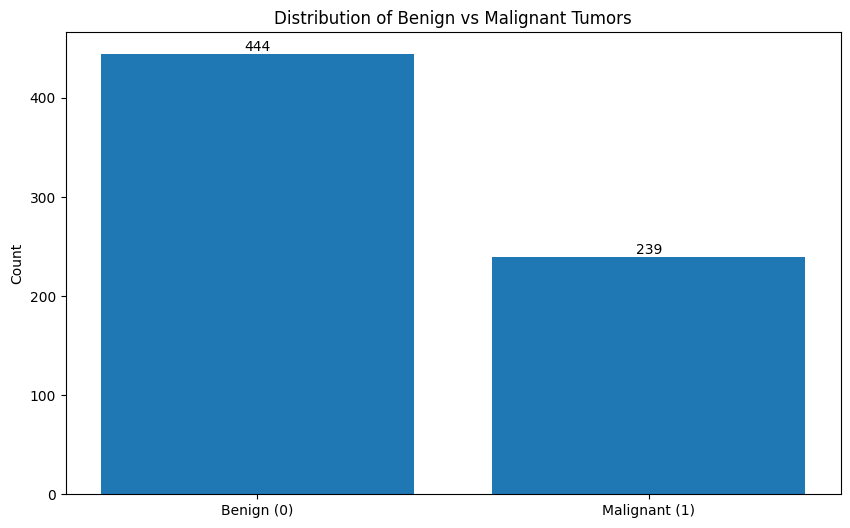

Percentages:
Benign: 65.01%
Malignant: 34.99%


In [3]:
# histogram of benign vs malignant - Daniel

counts = df['Class'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar([0, 1], counts, tick_label=['Benign (0)', 'Malignant (1)'])
plt.xticks([0, 1], ['Benign (0)', 'Malignant (1)'])
plt.title('Distribution of Benign vs Malignant Tumors')
plt.ylabel('Count')

for i, count in enumerate(counts):
    plt.text(i, count, str(count), ha='center', va='bottom')

plt.show()

total = len(df)
benign_pct = (df['Class'] == 0).sum() / total * 100
malignant_pct = (df['Class'] == 1).sum() / total * 100

print(f"Percentages:")
print(f"Benign: {benign_pct:.2f}%")
print(f"Malignant: {malignant_pct:.2f}%")

This bar chart shows the distribution of patients who have a benign or malignant breast cancer tumor\. A majority of patients have benign tumors at 65% with the other 35% having malignant tumors\. 

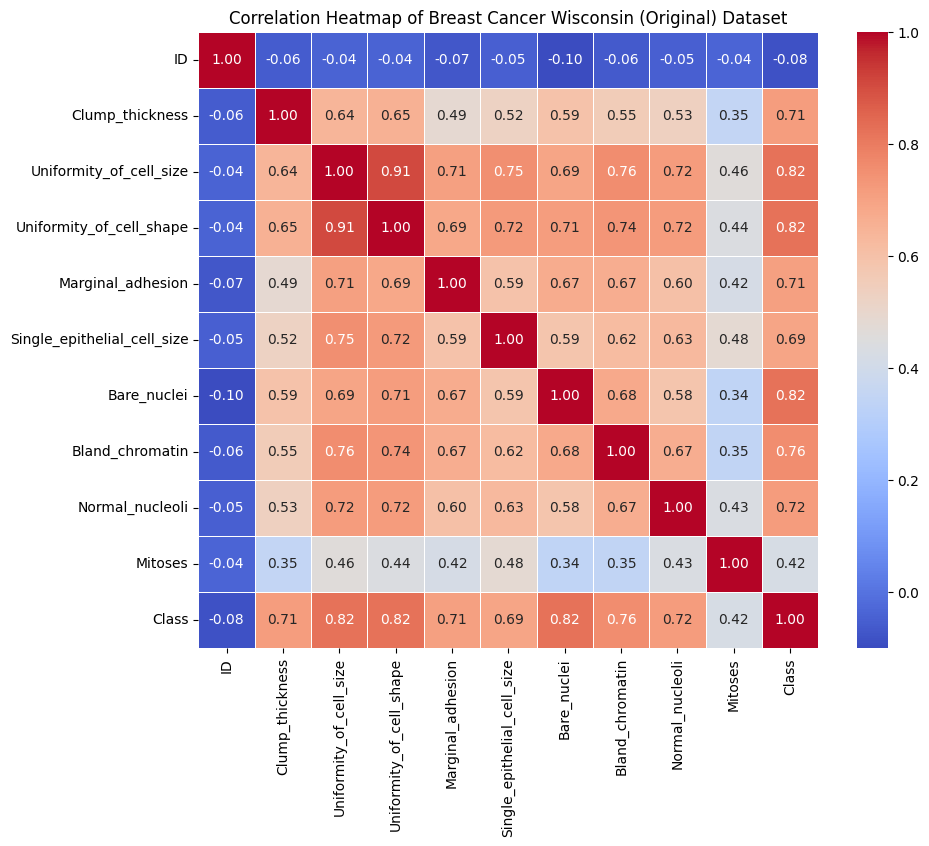

In [4]:
# Heatmap - Carolyn 

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Breast Cancer Wisconsin (Original) Dataset')
plt.show()

This heatmap shows the correlations between each of the features in the dataset\. Using this specific visualization would make it easy to identify which features are positively or negatively correlated\. 

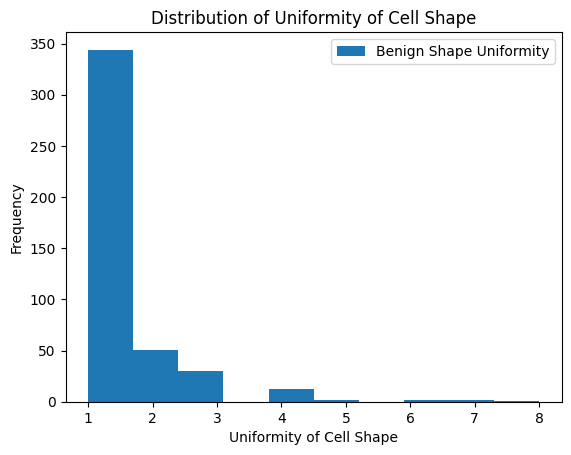

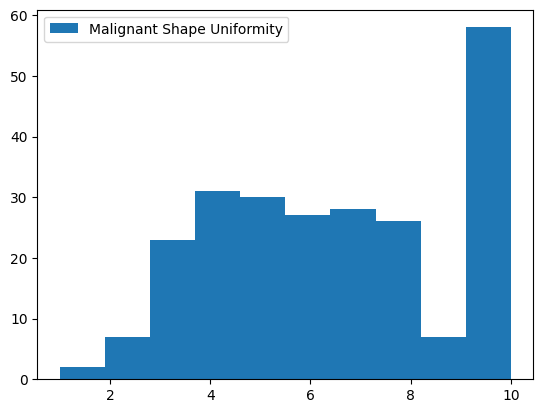

In [5]:
#Liam
#Graph showing distribution of shape uniformity malignant vs benign

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
df = pd.read_csv("cleaned_breast_cancer.csv")
df.head()
benign = df[df['Class'] == 0]
malignant = df[df['Class'] == 1]
benign_shape = benign['Uniformity_of_cell_shape']
malignant_shape = malignant['Uniformity_of_cell_shape']
plt.title('Distribution of Uniformity of Cell Shape')
plt.xlabel('Uniformity of Cell Shape')
plt.ylabel('Frequency')
plt.hist(benign_shape, label = 'Benign Shape Uniformity', bins = 10)
plt.legend()
plt.show()
plt.hist(malignant_shape, label = 'Malignant Shape Uniformity', bins = 10)
plt.legend()
plt.show()


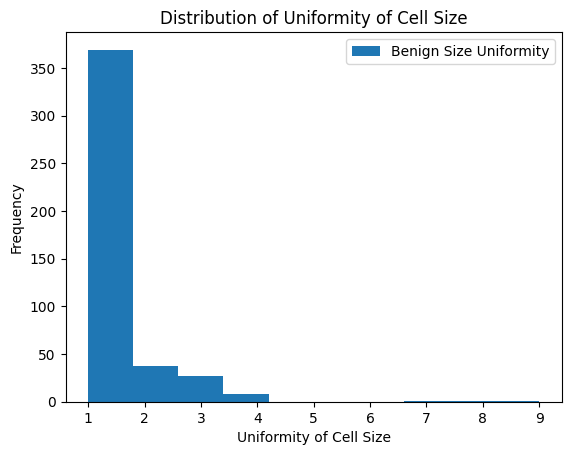

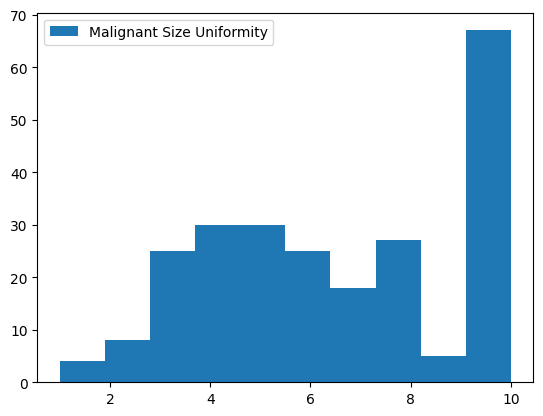

In [6]:
#Liam
#Same as above but with cell size instead of shape

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
df = pd.read_csv("cleaned_breast_cancer.csv")
df.head()
benign = df[df['Class'] == 0]
malignant = df[df['Class'] == 1]
benign_shape = benign['Uniformity_of_cell_size']
malignant_shape = malignant['Uniformity_of_cell_size']
plt.title('Distribution of Uniformity of Cell Size')
plt.xlabel('Uniformity of Cell Size')
plt.ylabel('Frequency')
plt.hist(benign_shape, label = 'Benign Size Uniformity', bins = 10)
plt.legend()
plt.show()
plt.hist(malignant_shape, label = 'Malignant Size Uniformity', bins = 10)
plt.legend()
plt.show()

## Tests

Hypothesis 1: Certain features of the dataset have a greater impact to whether a patient is likely to have a malignant breast cancer tumor\. 

In [7]:
# Pearson Correlation Tests - Daniel

features = ['Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 
           'Marginal_adhesion', 'Single_epithelial_cell_size', 'Bare_nuclei', 
           'Bland_chromatin', 'Normal_nucleoli', 'Mitoses']

print(f"{'Feature':<30} {'Correlation':<15}")
print("-" * 50)

correlations = {}

# Calculate Pearson correlations for each feature
for feature in features:
    correlation = df[feature].corr(df['Class'])
    correlations[feature] = correlation

sorted_correlations = dict(sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True))

for feature, correlation in sorted_correlations.items():
    print(f"{feature:<30} {correlation:>10}")

Feature                        Correlation    
--------------------------------------------------
Bare_nuclei                    0.8226958729964658
Uniformity_of_cell_shape       0.8218909476888707
Uniformity_of_cell_size        0.8208014428258734
Bland_chromatin                0.7582275545334322
Normal_nucleoli                0.7186771878756354
Clump_thickness                0.7147899263221591
Marginal_adhesion              0.7062941354660857
Single_epithelial_cell_size    0.6909581590873206
Mitoses                        0.4234479212952116


Here we see that using the Pearson Correlation, that there is a relation between many of the features and whether the corresponding patient has a malignant breast cancer tumor\. The three most correlated features are the Bare\_nuclei, Uniformity\_of\_cell\_shape, and Uniformity\_of\_cell\_size which all have a correlation of about 0\.82\. This means that they are highly correlated as that value is close to 1\. On the other hand, the least correlated feature is the Mitoses which has a correlation score of 0\.42\. This number is closer to 0 than it is 1 indicating that it is probably uncorrelated with whether that patient has a malignant tumor\. These scores are useful as they can tell us the most important features to look at\.

In [8]:
# Chi Square Tests - Aaron
df = pd.read_csv('cleaned_breast_cancer.csv')
features = ['Clump_thickness', 'Uniformity_of_cell_size', 
           'Uniformity_of_cell_shape', 'Marginal_adhesion', 'Single_epithelial_cell_size',
           'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses']
chi2_results = {}
for feature in features:
    contingency_table = pd.crosstab(df[feature], df['Class'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi2_results[feature] = {'Chi2 Statistic': chi2, 'p-value': p}
for feature, result in chi2_results.items():
    print(f"{feature}: Chi2 = {result['Chi2 Statistic']:.2f}, p-value = {result['p-value']:.5f}")


Clump_thickness: Chi2 = 378.08, p-value = 0.00000
Uniformity_of_cell_size: Chi2 = 539.79, p-value = 0.00000
Uniformity_of_cell_shape: Chi2 = 523.07, p-value = 0.00000
Marginal_adhesion: Chi2 = 390.06, p-value = 0.00000
Single_epithelial_cell_size: Chi2 = 447.86, p-value = 0.00000
Bare_nuclei: Chi2 = 489.01, p-value = 0.00000
Bland_chromatin: Chi2 = 453.21, p-value = 0.00000
Normal_nucleoli: Chi2 = 416.63, p-value = 0.00000
Mitoses: Chi2 = 191.97, p-value = 0.00000


We used Chi\-Square testing to see whether there are significant associations between each feature and the target variable\(Benign or Malignant\)\. We looked at each feature individually, concluding that Uniformity\_of\_cell\_size was the feature with the strongest association with the target variable\. We see that the p\-value is incredibly low showing 0\(although the number is just really small\) allowing us to conclude that each feature strongly correlates with what we're looking at\(the Target variable\)\. Even though mitoses holds a strong p\-value correlation, we see that it has the lowest Chi2 value, allowing us to conclude that it holds the weakest association with the target variable\. We can conclude that all of these features are helpful when looking at cells and deciding whether or not they are benign or malignant breast cancer cells\.

## Prediction Models

## Supervised Learning: K\-NN, Logistic Regression, K\-NN with Forward Feature Selection

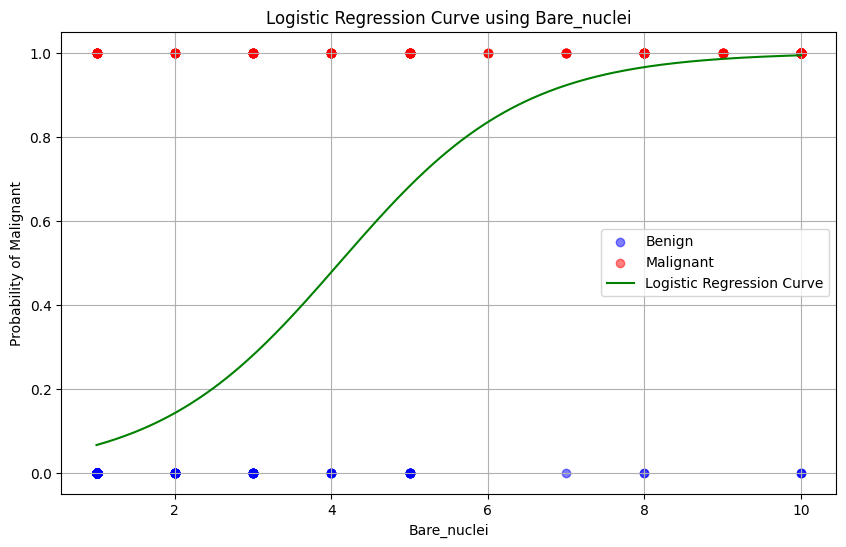


Logistic Regression Accuracy: 0.96


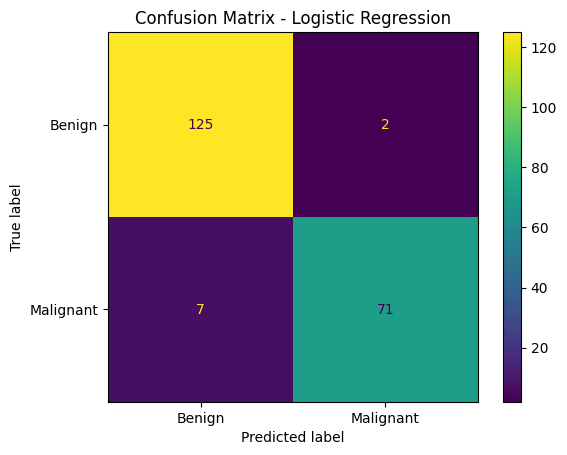


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       127
           1       0.97      0.91      0.94        78

    accuracy                           0.96       205
   macro avg       0.96      0.95      0.95       205
weighted avg       0.96      0.96      0.96       205



In [9]:
# Logistic Regression - Truman Fung

X = df.drop(['ID', 'Class'], axis=1)
Y = df['Class']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, Y_train)
Y_pred_log_reg = log_reg.predict(X_test)

most_correlated_feature = 'Bare_nuclei'
plt.figure(figsize=(10, 6))
X_feature = X[most_correlated_feature].values.reshape(-1, 1)
X_test_feature = np.linspace(X_feature.min(), X_feature.max(), 300).reshape(-1, 1)

log_reg_single = LogisticRegression(max_iter=1000)
log_reg_single.fit(X_feature, Y)
Y_pred_proba = log_reg_single.predict_proba(X_test_feature)[:, 1]

plt.scatter(X_feature[Y == 0], Y[Y == 0], color='blue', label='Benign', alpha=0.5)
plt.scatter(X_feature[Y == 1], Y[Y == 1], color='red', label='Malignant', alpha=0.5)
plt.plot(X_test_feature, Y_pred_proba, color='green', label='Logistic Regression Curve')

plt.xlabel(most_correlated_feature)
plt.ylabel('Probability of Malignant')
plt.title('Logistic Regression Curve using ' + most_correlated_feature)
plt.legend()
plt.grid(True)
plt.show()

print("\nLogistic Regression Accuracy: {:.2f}".format(accuracy_score(Y_test, Y_pred_log_reg)))

conf_matrix = confusion_matrix(Y_test, Y_pred_log_reg)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Benign", "Malignant"])
disp.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_log_reg))

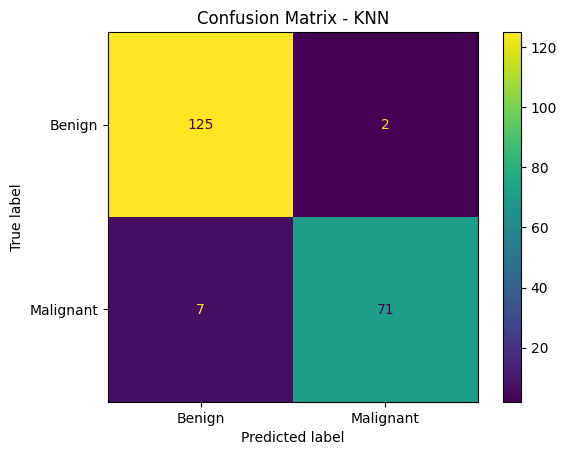


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       127
           1       0.97      0.91      0.94        78

    accuracy                           0.96       205
   macro avg       0.96      0.95      0.95       205
weighted avg       0.96      0.96      0.96       205



In [10]:
# K-NN - Truman

X = df.drop(['ID', 'Class'], axis=1)
Y = df['Class']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)
Y_pred_knn = knn.predict(X_test)

conf_matrix = confusion_matrix(Y_test, Y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Benign", "Malignant"])
disp.plot()
plt.title('Confusion Matrix - KNN')
plt.show()

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_knn))


Selected features: ['Uniformity_of_cell_shape', 'Single_epithelial_cell_size', 'Clump_thickness', 'Bland_chromatin']
Model accuracy with 4 features: 0.9635036496350365


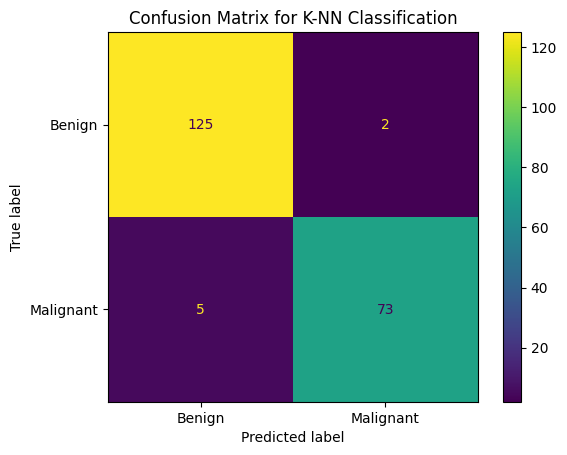


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       127
           1       0.97      0.94      0.95        78

    accuracy                           0.97       205
   macro avg       0.97      0.96      0.96       205
weighted avg       0.97      0.97      0.97       205



In [11]:
# KNN with Forward Feature Selection - Daniel

# Forward Feature Selection
from sklearn.metrics import ConfusionMatrixDisplay

tumor_class = df['Class']
features = ['Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 
           'Marginal_adhesion', 'Single_epithelial_cell_size', 'Bare_nuclei', 
           'Bland_chromatin', 'Normal_nucleoli', 'Mitoses']
X = df[features]

selected_features = []
best_score = 0
n_features = 4 

for i in range(n_features):
    best_new_score = 0
    best_feature = None
    
    for feature in features:
        if feature not in selected_features:
            current_features = selected_features + [feature]
            X_subset = X[current_features]
            
            X_train, X_test, y_train, y_test = train_test_split(X_subset, tumor_class, test_size=0.2, random_state=42)
            model = LogisticRegression(random_state=42)
            model.fit(X_train, y_train)
            
            score = accuracy_score(y_test, model.predict(X_test))
            
            if score > best_new_score:
                best_new_score = score
                best_feature = feature
    
    if best_feature:
        selected_features.append(best_feature)
        best_score = best_new_score

print("\nSelected features:", selected_features)

# K-NN
X_final = X[selected_features]
X_train, X_test, y_train, y_test = train_test_split(X_final, tumor_class, test_size=0.2, random_state=42)
final_model = LogisticRegression(random_state=42)
final_model.fit(X_train, y_train)
final_score = accuracy_score(y_test, final_model.predict(X_test))
print(f"Model accuracy with {n_features} features: {final_score}")

X = df[selected_features]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Benign", "Malignant"])
disp.plot()
plt.title("Confusion Matrix for K-NN Classification")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

### K\-NN vs\. K\-NN with Forward Feature Selection vs\. Logistic Regression

We performed K\-NN using all the features in the dataset and K\-NN with the four most correlated features of the dataset to figure out which model was more accurate at predicting whether a tumor was malignant or benign\. We used Forward Feature Selection \(FFS\) to determine which were the four most important features in predicting a diagnosis\. Regular K\-NN had an accuracy of 0\.96 while K\-NN with FFS had an accuracy of 0\.97\. Regular K\-NN had a recall of 0\.91 on malignant while K\-NN with FFS had a recall of 0\.94\. The recall is more important as we'd rather misdiagnose a patient as having a malignant tumor rather than incorrectly saying that they don't\. Therefore, the K\-NN with Forward Feature Selection turned out to be a more accurate model\.

Logistic Regression's confusion matrix yielded the same results as the K\-NN confusion matrix and also yields a very similar result to the K\-NN with forward feature selection\. All yield close or equal to 0\.96 accuracy for determining if a tumor is truly benign or malignant\. Additionally Logistic Regression does worse in recall for the malignant tumors when compared to the K\-NN with Forward Feature Selection\. As further reiterated K\-NN with forward feature selection has more desired results from this case since higher recall is more important in diagnosing a tumor's condition\.

## Unsupervised Learning: K\-Means vs DBSCAN

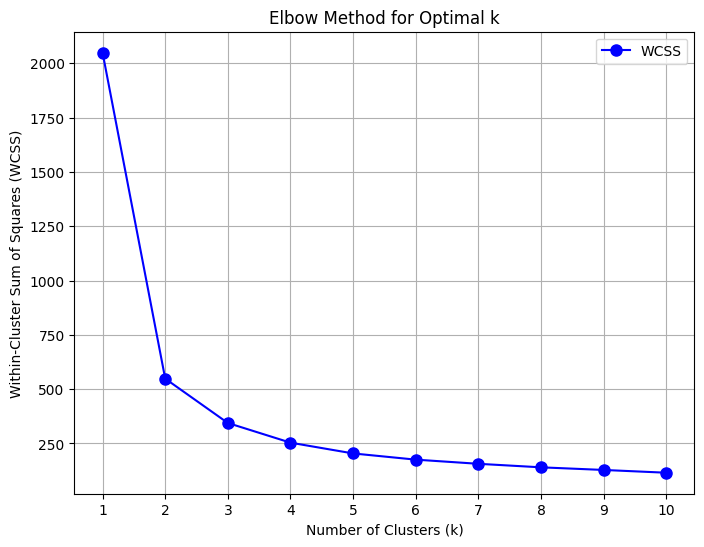

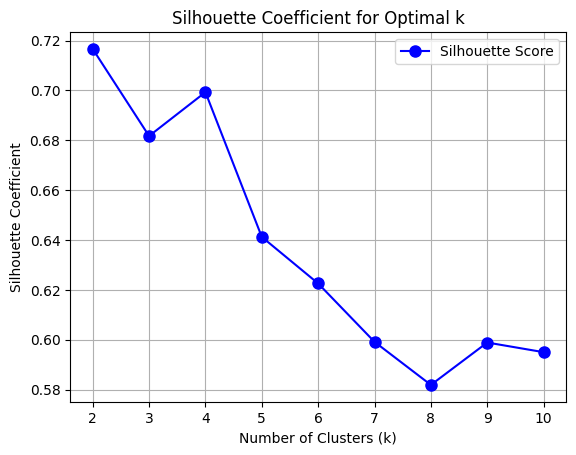

Optimal k-value: 2


In [12]:
# Elbow Method Evaluation - Carolyn

features = df[['Bare_nuclei', 'Uniformity_of_cell_shape', 'Uniformity_of_cell_size']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

wcss = [] 
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_values, wcss, 'bo-', markersize=8, label='WCSS')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(scaled_features)
    labels = kmeans.labels_
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, 'bo-', markersize=8, label='Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Coefficient')
plt.title('Silhouette Coefficient for Optimal k')
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal k-value: 2")

### Elbow Method

The elbow method was used to evaluate the clustering performance using the sum of squared distances between each point and the centroid of its cluster\. In doing so, it was discovered that the optimal number of clusters to be used for K\-Means clustering is 2\. The silhouette coefficient was also used to further support this finding\.

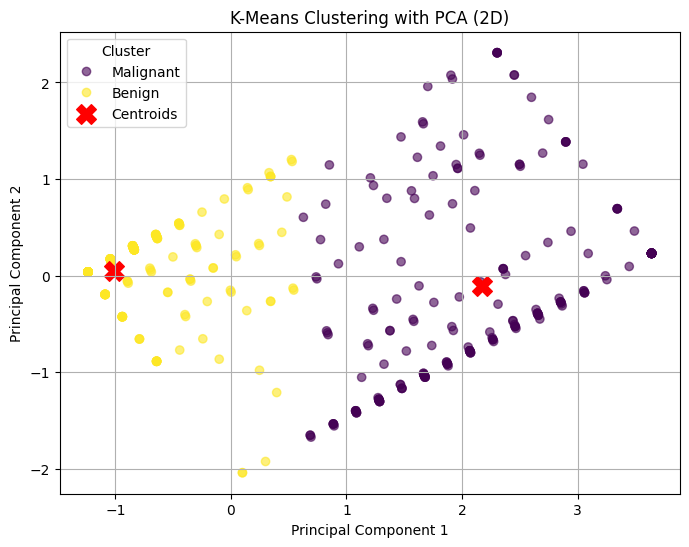

Silhouette Score for K-Means: 0.7166248965205936


In [13]:
# K-Means Clustering - Nicole

k = 2
kmeans = KMeans(n_clusters = k, random_state = 1)

df['KM_Cluster'] = kmeans.fit_predict(scaled_features)

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

centroids = kmeans.cluster_centers_
centroid_2d = pca.transform(centroids)

cluster_class_mapping = {}
for cluster in range(k):
    # Find the most common class label in each cluster
    majority_class = df[df['KM_Cluster'] == cluster]['Class'].mode()[0]
    cluster_class_mapping[cluster] = majority_class

df['Mapped_Class'] = df['KM_Cluster'].map(cluster_class_mapping)


plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], c=df['KM_Cluster'], cmap='viridis', alpha=0.6)

centroid_plot = plt.scatter(centroid_2d[:, 0], centroid_2d[:, 1], c='red', marker='X', s=200, label='Centroids')

handles, labels = scatter.legend_elements()
labels = ['Malignant' if int(label.replace('$\\mathdefault{','').replace('}$','')) == 0 else 'Benign' for label in labels]

plt.legend(handles + [centroid_plot], labels + ['Centroids'], title="Cluster", loc="upper left")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering with PCA (2D)')
plt.grid(True)
plt.show()

kmeans_silhouette = silhouette_score(scaled_features, df['KM_Cluster'])
print(f"Silhouette Score for K-Means: {kmeans_silhouette}")

### K\-Means Clustering

K\-Means Clustering was used to reveal natural clustering from the dataset\. In this case, we want to see if there is any natural clustering when looking at the three most correlated features taken from the Pearson Correlation Test done for Hypothesis 1 — 'Bare\_nuclei', 'Uniformity\_of\_cell\_shape', 'Uniformity\_of\_cell\_size'\. By using only the most correlated features, K\-means can avoid noisy data and better calculate and predict\. For better visualization, Principal Component Analysis \(PCA\) was used to reduce the 3\-feature dimensionality to just 2\. In doing so, we can simplify the data but also retain important information needed to accurately assign cluster labels\. The k value is 2 to represent the two clusters we want to divide the dataset into, Benign and Malignant\. 

Analyzing the visualization above, we can see there seems to be a natural clustering for the two cluster\. Purple represent the malignant cluster while yellow represents benign\. To help determine which clustering algorithm is better between K\-Means and DBSCAN, the silhouette score was calculated\. K\-Means resulted in a score of approximately 0\.72\. Since a score of 0\.72 is closer to 1, this means K\-Means had a decent performance in creating well\-define clustering with clear separation between the clusters\.

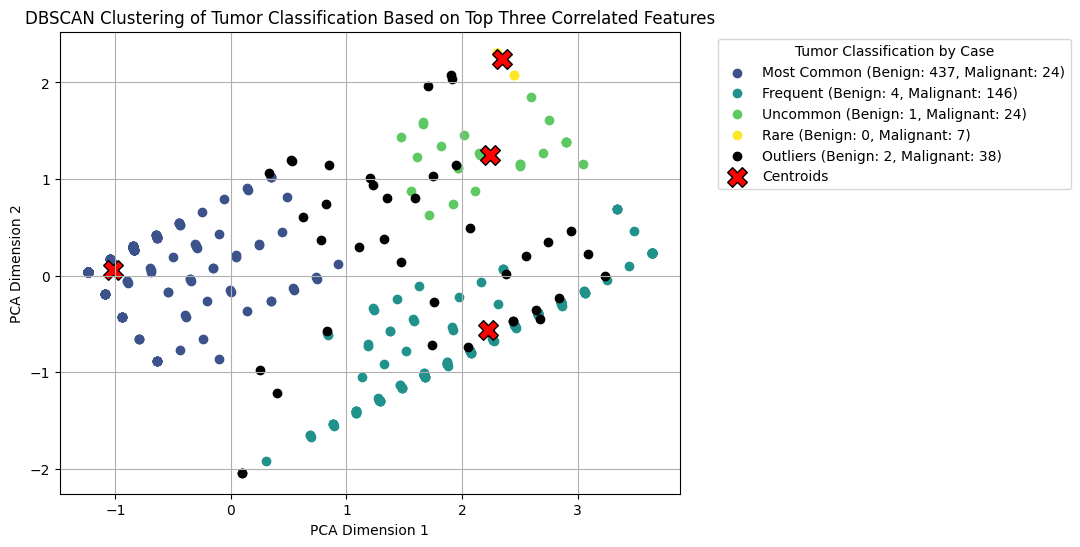

Cluster Purity:
 Cluster
-1    0.950000
 0    0.947939
 1    0.973333
 2    0.960000
 3    1.000000
dtype: float64
Silhouette Score: 0.6203813021496178


In [14]:
# DBSCAN - Carolyn

dbscan = DBSCAN(eps=0.5, min_samples=7)
df['Cluster'] = dbscan.fit_predict(scaled_features)

cluster_summary = df.groupby(['Cluster', 'Class']).size().unstack(fill_value=0)

descriptive_labels = {
    0: "Most Common",
    1: "Frequent",
    2: "Uncommon",
    3: "Rare",
    -1: "Outliers"
}
cluster_labels = {}
for cluster, counts in cluster_summary.iterrows():
    benign_count = counts[0] if 0 in counts else 0
    malignant_count = counts[1] if 1 in counts else 0
    if cluster in descriptive_labels:
        cluster_labels[cluster] = f"{descriptive_labels[cluster]} (Benign: {benign_count}, Malignant: {malignant_count})"
    else:
        cluster_labels[cluster] = f"Cluster {cluster} (Benign: {benign_count}, Malignant: {malignant_count})"

plt.figure(figsize=(8, 6))
unique_labels = set(df['Cluster'])

centroids = {}
for label in unique_labels:
    if label != -1:  # Skip noise points
        cluster_points = pca_features[df['Cluster'] == label]
        centroids[label] = cluster_points.mean(axis=0)

for label in unique_labels:
    if label == -1:  
        color = 'k'  # Color black for noise
        cluster_label = cluster_labels[label]
    else:
        color = plt.cm.viridis(float(label + 1) / (max(unique_labels) + 1))
        cluster_label = cluster_labels[label]

    plt.scatter(
        pca_features[df['Cluster'] == label, 0],
        pca_features[df['Cluster'] == label, 1],
        c=[color], label=cluster_label
    )

centroid_coords = [centroid for centroid in centroids.values()]
plt.scatter(
    [coord[0] for coord in centroid_coords],  # X-coordinates of centroids
    [coord[1] for coord in centroid_coords],  # Y-coordinates of centroids
    c='red', marker='X', s=200, edgecolor='k', label='Centroids'
)
    
plt.title("DBSCAN Clustering of Tumor Classification Based on Top Three Correlated Features")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), title="Tumor Classification by Case")
plt.grid(True)
plt.show()

cluster_purity = cluster_summary.max(axis=1) / cluster_summary.sum(axis=1)
print("Cluster Purity:\n", cluster_purity)
dbscan_silhouette = silhouette_score(scaled_features, df['Cluster'])
print(f"Silhouette Score: {dbscan_silhouette}")

### DBSCAN Clustering

The DBSCAN Clustering method was used to reveal patterns and clusters in the cleaned dataset based on the three features that are most\-correlated with malignant tumors: 'Bare\_nuclei', 'Uniformity\_of\_cell\_shape', and 'Uniformity\_of\_cell\_size' \(given from Pearson Correlation test\)\. Principal Component Analysis \(PCA\) was used to transform the original three features into a new set of features, which reduces the number of features \(or dimensions\) to two while retaining as much meaningful variation or information as possible\. This was done in order to better display the patterns within these features\. The clusters in this DBSCAN represent groups of tumor data points that share similar characteristics based on their 'Bare\_nuclei', 'Uniformity\_of\_cell\_shape', and 'Uniformity\_of\_cell\_size' values\.

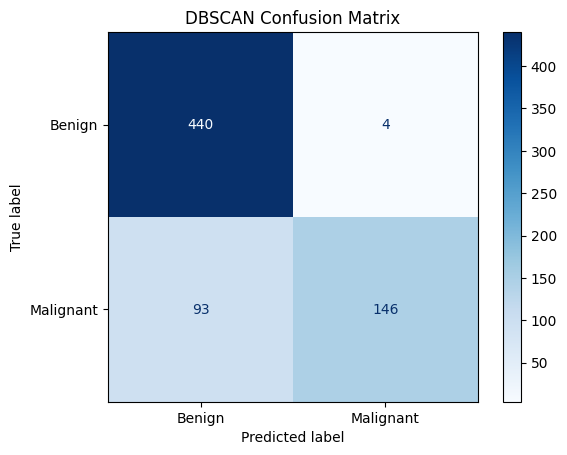

DBSCAN Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.99      0.90       444
           1       0.97      0.61      0.75       239

    accuracy                           0.86       683
   macro avg       0.90      0.80      0.83       683
weighted avg       0.88      0.86      0.85       683



In [15]:
# DBSCAN Confusion Matrix - Carolyn

cluster_mapping = {0: 0, 1: 1}
adjusted_labels = df['Cluster'].map(cluster_mapping).fillna(0)

conf_matrix = confusion_matrix(df['Class'], adjusted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Blues")
plt.title("DBSCAN Confusion Matrix")
plt.show()

print("DBSCAN Classification Report:\n", classification_report(df["Class"], adjusted_labels, zero_division=0))

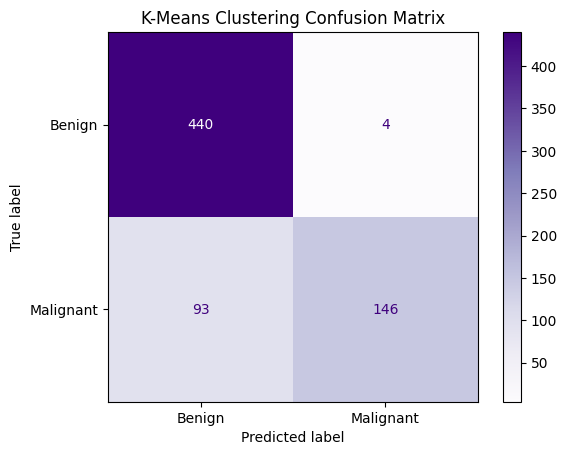

K-Means Clustering Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.99      0.90       444
           1       0.97      0.61      0.75       239

    accuracy                           0.86       683
   macro avg       0.90      0.80      0.83       683
weighted avg       0.88      0.86      0.85       683



In [16]:
# K-Means Clustering Confusion Matrix - Nicole

cluster_mapping = {0: 1, 1: 0}
KM_adjusted_labels = df['KM_Cluster'].map(cluster_mapping)

cm = confusion_matrix(df['Class'], KM_adjusted_labels)
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Purples")
plt.title("K-Means Clustering Confusion Matrix")
plt.show()

print("K-Means Clustering Classification Report:\n", classification_report(df["Class"], adjusted_labels, zero_division=0))

### Confusion Matrix: K\-Means vs DBSCAN

Comparing the confusion matrices and their classification reports, we can determine which classification model performed better overall by looking at the f1\-scores \(score of 1 indicating perfect classification\)\. In this case, the models shared the same f1\-scores for all rows except for the row with class 1 \(malignant\)\. Off by 0\.01, K\-Means has the higher f1\-score of 0\.76 while DBSCAN has a f1\-score of 0\.75\. Besides the f1\-scores, the models also differed in the recall score for class 1\. Since K\-means has the higher f1\-score than DBSCAN, this means K\-Means is classification model with the better performance for our dataset\. 

But since we are dealing with medical diagnoses, f1\-score alone cannot tell us which model performs better\. We also need to look at the recall score because we want to minimize false negatives especially for something as serious as cancer\. In this case, the only index the models differ in their classification report is in the recall score for class 1 \(malignant\)\. K\-Means resulted in a higher recall score of 0\.63 than the recall score of DBSCAN\. This means K\-Means is better in accurately identifying the true positives and minimizing the false negative\. It's better to have more false positives than false negatives\.

After analyzing the confusions matrices and comparing the f1\-scores and recall scores from their classification reports, K\-Means proved to be the better classification model than DBSCAN\.

## Conclusion 

By analyzing the different features of the Breast Cancer Wisconsin dataset, we were able to see that many of the features in the dataset had a very strong correlation to whether a patient had a malignant or benign breast cancer tumor\. Our original hypothesis that the tumor diagnoses had could be predicted based on the condition of the cells in the tumor turned out to be true\. However, the most important factors turned out to be Uniformity\_of\_cell\_shape, Single\_epithelial\_cell\_size, Clump\_thickness, Bland\_chromatin as the combination of these four features led to the highest results in our predictions\. Our supervised models: logistic regression, K\-NN, and K\-NN with Forward Feature Selection all had an accuracy greater than 96% on the test data\. Our unsupervised models K\-Means and DBSCAN had an accuracy greater than 86%\. From this we can determine that the supervised learning techniques proved to be more accurate overall, but the unsupervised data was still fairly accurate at predicting a diagnosis\. 